# 05 — Optimización de Hiperparámetros

**Objetivo:** Optimizar los modelos campeones binario y multiclase usando `RandomizedSearchCV`.  
Este notebook **carga los resultados CV desde CSV** para identificar los campeones,  
luego entrena solo los modelos necesarios para el tuning.

**Modelos optimizados:**
- **Gaussian Naïve Bayes** (campeón binario): `var_smoothing` ∈ {1e-11 … 1e-6}
- **Logistic Regression** (campeón multiclase): `C`, `penalty`, `solver`

**Estrategia:** `RandomizedSearchCV` con `scoring=f1_macro`, `Stratified 5-Fold`, `n_iter=30`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
os.chdir(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

REPORTING_DIR = "data/08_reporting"
bin_cv = pd.read_csv(f"{REPORTING_DIR}/binary_cv_results.csv")
mul_cv = pd.read_csv(f"{REPORTING_DIR}/multiclass_cv_results.csv")

champ_bin    = bin_cv.sort_values("F1-Score_mean", ascending=False).iloc[0]["Model"]
champ_mul    = mul_cv.sort_values("F1-Score_mean", ascending=False).iloc[0]["Model"]
f1_base_bin  = bin_cv.sort_values("F1-Score_mean", ascending=False).iloc[0]["F1-Score_mean"]
f1_base_mul  = mul_cv.sort_values("F1-Score_mean", ascending=False).iloc[0]["F1-Score_mean"]

print(f"Campeón binario:    {champ_bin} — F1 base = {f1_base_bin:.4f}")
print(f"Campeón multiclase: {champ_mul} — F1 base = {f1_base_mul:.4f}")

Campeón binario:    gaussian_nb — F1 base = 0.2676
Campeón multiclase: logistic_regression — F1 base = 0.2895


In [2]:
from ev_parcial2_gonzalez.modeling.train import load_data, prepare_targets
from ev_parcial2_gonzalez.modeling.preprocessing import build_preprocessor
from ev_parcial2_gonzalez.modeling.config import TEST_SIZE, RANDOM_STATE
from ev_parcial2_gonzalez.modeling.model_training import get_supervised_classifiers, build_classification_pipeline
from ev_parcial2_gonzalez.modeling.hyperparameter_tuning import run_randomized_search, get_param_grid, compare_before_after
from ev_parcial2_gonzalez.modeling.utils import save_model
from sklearn.model_selection import train_test_split

df = load_data()
X, y_bin, y_mul = prepare_targets(df)
preprocessor = build_preprocessor()

X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=RANDOM_STATE)
_, _, ym_train, ym_test = train_test_split(
    X, y_mul, test_size=TEST_SIZE, stratify=y_mul, random_state=RANDOM_STATE)

classifiers = get_supervised_classifiers()
bin_pipe = build_classification_pipeline(preprocessor, classifiers[champ_bin])
mul_pipe = build_classification_pipeline(preprocessor, classifiers[champ_mul])
print("Pipelines preparados (1 binario + 1 multiclase)")

2026-05-22 19:45:44 | ev_parcial2_gonzalez.modeling.train | INFO     | Dataset cargado: (3000, 33)
2026-05-22 19:45:44 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Numeric features (6): ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Total Training Cost', 'Seniority_Years', 'Current Employee Rating']
2026-05-22 19:45:44 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Categorical features (12): ['Title', 'BusinessUnit', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'DepartmentType', 'Division', 'State', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Gender_Male']
2026-05-22 19:45:44 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Preprocessor construido exitosamente.


Pipelines preparados (1 binario + 1 multiclase)


## 1. Optimización del Campeón Binario: Gaussian Naïve Bayes

**Hiperparámetro clave:** `var_smoothing` — porción de varianza máxima añadida a las varianzas  
por feature para estabilidad numérica.  
- Valor pequeño → modelo más ajustado a los datos (menos suavizado)  
- Valor grande → mayor regularización (más suavizado, mejor generalización)

In [3]:
grid_bin = get_param_grid(champ_bin)
print(f"Grid de búsqueda para {champ_bin}:")
for k, v in grid_bin.items():
    print(f"  {k}: {v}")

print(f"\nIniciando RandomizedSearchCV (n_iter=30)...")
rs_bin = run_randomized_search(bin_pipe, X_train, yb_train, grid_bin, n_iter=30)
print(f"Mejor F1-Score CV: {rs_bin.best_score_:.4f}")
print(f"Mejores parámetros: {rs_bin.best_params_}")

2026-05-22 19:45:49 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | ▶ Iniciando: run_randomized_search


Grid de búsqueda para gaussian_nb:
  classifier__var_smoothing: [1e-11, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06]

Iniciando RandomizedSearchCV (n_iter=30)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


2026-05-22 19:45:53 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | Mejor score (f1_macro): 0.3773
2026-05-22 19:45:53 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | Mejores parámetros: {'classifier__var_smoothing': 1e-11}
2026-05-22 19:45:53 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | ✔ Completado: run_randomized_search (4.50s)


Mejor F1-Score CV: 0.3773
Mejores parámetros: {'classifier__var_smoothing': 1e-11}


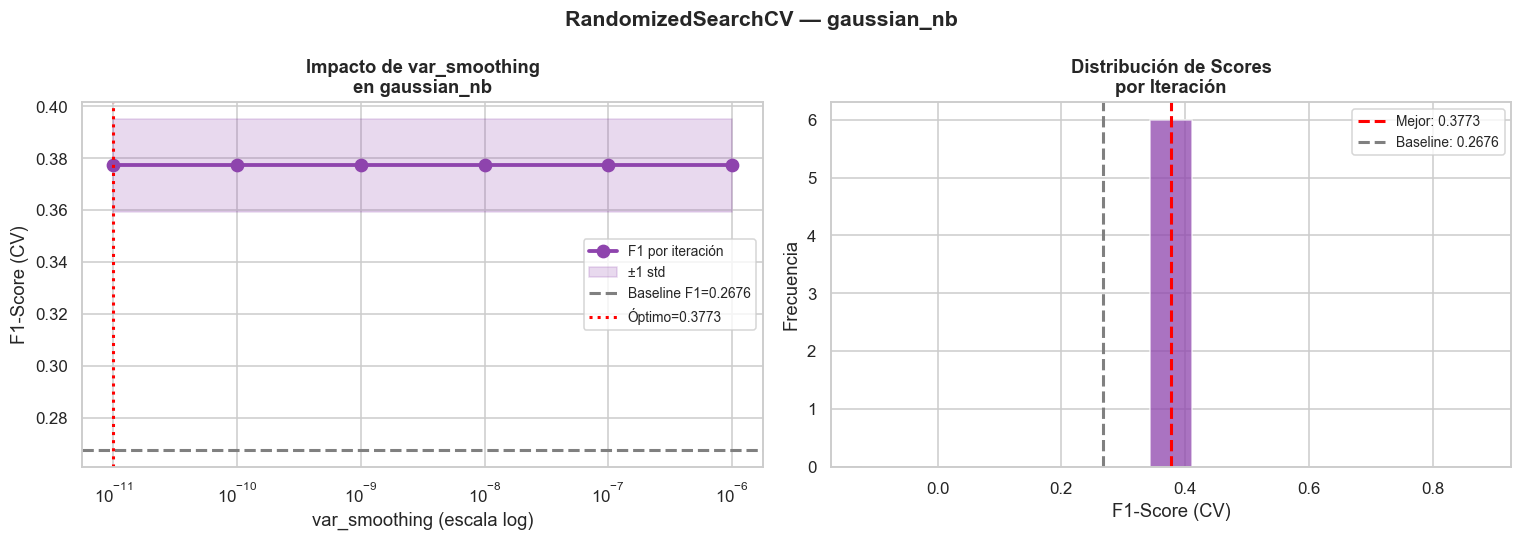

In [4]:
cv_results_bin = pd.DataFrame(rs_bin.cv_results_)
param_col = [c for c in cv_results_bin.columns if "param_" in c][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cv_plot = cv_results_bin.sort_values(param_col)
axes[0].semilogx(cv_plot[param_col].astype(float), cv_plot["mean_test_score"],
                 "o-", color="#8e44ad", lw=2.5, ms=8, label="F1 por iteración")
axes[0].fill_between(
    cv_plot[param_col].astype(float),
    cv_plot["mean_test_score"] - cv_plot["std_test_score"],
    cv_plot["mean_test_score"] + cv_plot["std_test_score"],
    alpha=0.2, color="#8e44ad", label="±1 std")
axes[0].axhline(f1_base_bin, color="gray", ls="--", lw=2,
                label=f"Baseline F1={f1_base_bin:.4f}")
best_val = float(list(rs_bin.best_params_.values())[0])
axes[0].axvline(best_val, color="red", ls=":", lw=2,
                label=f"Óptimo={rs_bin.best_score_:.4f}")
axes[0].set_xlabel("var_smoothing (escala log)")
axes[0].set_ylabel("F1-Score (CV)")
axes[0].set_title(f"Impacto de var_smoothing\nen {champ_bin}", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].hist(cv_results_bin["mean_test_score"], bins=15,
             color="#8e44ad", alpha=0.75, edgecolor="white")
axes[1].axvline(rs_bin.best_score_, color="red", ls="--", lw=2,
                label=f"Mejor: {rs_bin.best_score_:.4f}")
axes[1].axvline(f1_base_bin, color="gray", ls="--", lw=2,
                label=f"Baseline: {f1_base_bin:.4f}")
axes[1].set_xlabel("F1-Score (CV)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Scores\npor Iteración", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle(f"RandomizedSearchCV — {champ_bin}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/plots/tuning_gnb.png", bbox_inches="tight")
plt.show()

## 2. Optimización del Campeón Multiclase: Logistic Regression

**Hiperparámetros clave:**
- `C`: inverso de la fuerza de regularización (mayor C = menos regularización = más ajuste)
- `penalty`: tipo de regularización (L2 estándar, L1 para selección de features)
- `solver`: algoritmo de optimización (lbfgs eficiente para datasets medianos, saga soporta L1)

In [5]:
grid_mul = get_param_grid(champ_mul)

# Ampliar el grid si no incluye C
if not any("__C" in k for k in grid_mul):
    grid_mul.update({
        "classifier__C": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0],
        "classifier__max_iter": [500, 1000, 2000],
        "classifier__solver": ["lbfgs", "saga"]
    })

print(f"Grid de búsqueda para {champ_mul}:")
for k, v in grid_mul.items():
    print(f"  {k}: {v}")

print(f"\nIniciando RandomizedSearchCV (n_iter=30)...")
rs_mul = run_randomized_search(mul_pipe, X_train, ym_train, grid_mul, n_iter=30)
print(f"Mejor F1-macro CV: {rs_mul.best_score_:.4f}")
print(f"Mejores parámetros: {rs_mul.best_params_}")

2026-05-22 19:45:56 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | ▶ Iniciando: run_randomized_search


Grid de búsqueda para logistic_regression:
  classifier__C: [0.01, 0.1, 1, 10, 100]
  classifier__penalty: ['l2']
  classifier__solver: ['lbfgs', 'saga']

Iniciando RandomizedSearchCV (n_iter=30)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


2026-05-22 19:55:56 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | Mejor score (f1_macro): 0.2511
2026-05-22 19:55:56 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | Mejores parámetros: {'classifier__solver': 'saga', 'classifier__penalty': 'l2', 'classifier__C': 1}
2026-05-22 19:55:56 | ev_parcial2_gonzalez.modeling.hyperparameter_tuning | INFO     | ✔ Completado: run_randomized_search (599.97s)


Mejor F1-macro CV: 0.2511
Mejores parámetros: {'classifier__solver': 'saga', 'classifier__penalty': 'l2', 'classifier__C': 1}


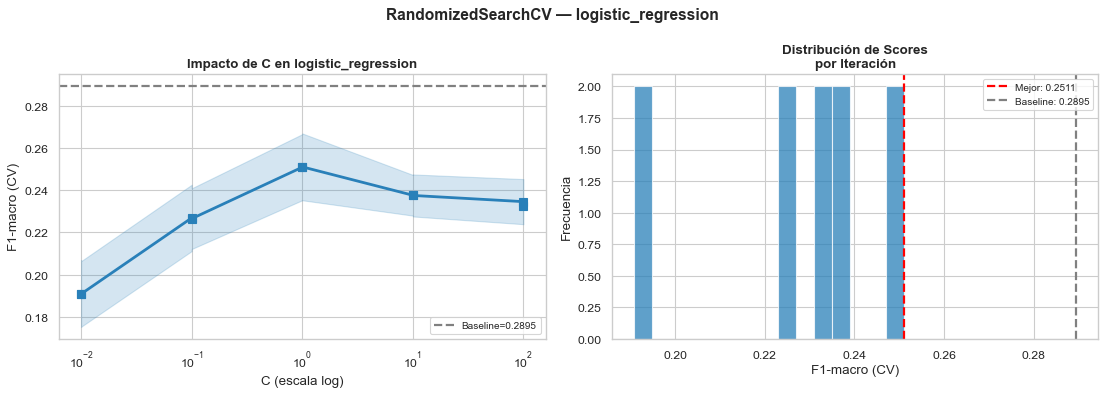

In [20]:
from IPython.display import display, Image

cv_results_mul = pd.DataFrame(rs_mul.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c_col = [c for c in cv_results_mul.columns if "__C" in c and "param_" in c]
if c_col:
    cv_c = cv_results_mul[[c_col[0], "mean_test_score", "std_test_score"]].dropna()
    cv_c = cv_c.sort_values(c_col[0])
    axes[0].semilogx(cv_c[c_col[0]].astype(float), cv_c["mean_test_score"],
                     "s-", color="#2980b9", lw=2.5, ms=8)
    axes[0].fill_between(
        cv_c[c_col[0]].astype(float),
        cv_c["mean_test_score"] - cv_c["std_test_score"],
        cv_c["mean_test_score"] + cv_c["std_test_score"],
        alpha=0.2, color="#2980b9")
    axes[0].axhline(f1_base_mul, color="gray", ls="--", lw=2,
                    label=f"Baseline={f1_base_mul:.4f}")
    axes[0].set_xlabel("C (escala log)")
    axes[0].set_ylabel("F1-macro (CV)")
    axes[0].set_title(f"Impacto de C en {champ_mul}", fontweight="bold")
    axes[0].legend(fontsize=9)

axes[1].hist(cv_results_mul["mean_test_score"], bins=15,
             color="#2980b9", alpha=0.75, edgecolor="white")
axes[1].axvline(rs_mul.best_score_, color="red", ls="--", lw=2,
                label=f"Mejor: {rs_mul.best_score_:.4f}")
axes[1].axvline(f1_base_mul, color="gray", ls="--", lw=2,
                label=f"Baseline: {f1_base_mul:.4f}")
axes[1].set_xlabel("F1-macro (CV)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Scores\npor Iteración", fontweight="bold")
axes[1].legend(fontsize=9)

fig.suptitle(f"RandomizedSearchCV — {champ_mul}", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("results/plots/tuning_lr.png", bbox_inches="tight", dpi=80)
plt.close(fig)
display(Image(filename="results/plots/tuning_lr.png", width=700))

## 3. Comparación Before vs After — Ambos Modelos

In [16]:
tabla_before_after = pd.DataFrame([
    {
        "Tarea": "Binaria (Fuga)",
        "Modelo": champ_bin,
        "F1 Base": round(f1_base_bin, 4),
        "F1 Tuneado": round(rs_bin.best_score_, 4),
        "Mejora Abs.": round(rs_bin.best_score_ - f1_base_bin, 4),
        "Mejora Rel.": f"+{(rs_bin.best_score_ - f1_base_bin)/f1_base_bin*100:.1f}%",
        "Mejor Params": str(rs_bin.best_params_)
    },
    {
        "Tarea": "Multiclase (Performance)",
        "Modelo": champ_mul,
        "F1 Base": round(f1_base_mul, 4),
        "F1 Tuneado": round(rs_mul.best_score_, 4),
        "Mejora Abs.": round(rs_mul.best_score_ - f1_base_mul, 4),
        "Mejora Rel.": f"+{(rs_mul.best_score_ - f1_base_mul)/f1_base_mul*100:.1f}%",
        "Mejor Params": str(rs_mul.best_params_)
    }
])

print("=== Before vs After ===")
display(tabla_before_after)
tabla_before_after.to_csv(f"{REPORTING_DIR}/tuning_comparison.csv", index=False)
print("\nGuardado en data/08_reporting/tuning_comparison.csv")

=== Before vs After ===


,Tarea,Modelo,F1 Base,F1 Tuneado,Mejora Abs.,Mejora Rel.,Mejor Params
0,Binaria (Fuga),gaussian_nb,0.2676,0.3773,0.1098,+41.0%,{'classifier__var_smoothing': 1e-11}
1,Multiclase (Performance),logistic_regression,0.2895,0.2511,-0.0384,+-13.3%,"{'classifier__solver': 'saga', 'classifier__pe..."



Guardado en data/08_reporting/tuning_comparison.csv


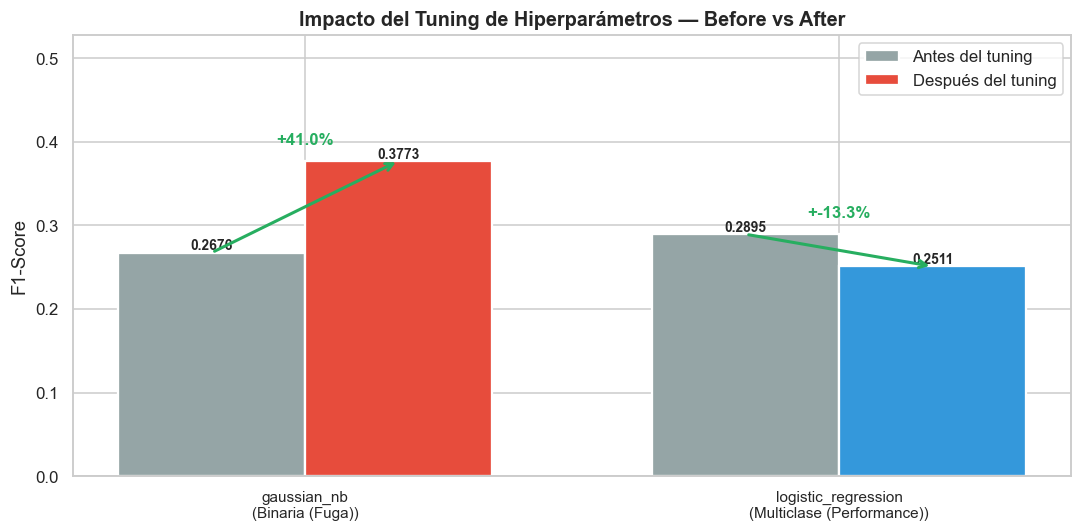

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

modelos_names = [champ_bin, champ_mul]
f1_antes   = [f1_base_bin, f1_base_mul]
f1_despues = [rs_bin.best_score_, rs_mul.best_score_]
labels_tareas = ["Binaria (Fuga)", "Multiclase (Performance)"]

x = np.arange(len(modelos_names))
width = 0.35

ax.bar(x - width/2, f1_antes, width, label="Antes del tuning",
       color="#95a5a6", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, f1_despues, width, label="Después del tuning",
               color=["#e74c3c", "#3498db"], edgecolor="white", linewidth=1.5)

for vals in [f1_antes, f1_despues]:
    for xi, v in zip(x + [-width/2, width/2][vals == f1_despues], vals):
        ax.text(xi, v + 0.003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

for i in range(len(x)):
    pct = (f1_despues[i] - f1_antes[i]) / f1_antes[i] * 100
    ax.annotate("",
                xy=(x[i] + width/2, f1_despues[i]),
                xytext=(x[i] - width/2, f1_antes[i]),
                arrowprops={"arrowstyle": "->", "color": "#27ae60", "lw": 2})
    ax.text(x[i], max(f1_antes[i], f1_despues[i]) + 0.02,
            f"+{pct:.1f}%", ha="center", fontsize=11, fontweight="bold", color="#27ae60")

ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n({t})" for m, t in zip(modelos_names, labels_tareas)], fontsize=10)
ax.set_ylabel("F1-Score")
ax.set_ylim(0, max(f1_despues) * 1.4)
ax.set_title("Impacto del Tuning de Hiperparámetros — Before vs After",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("results/plots/tuning_before_after.png", bbox_inches="tight")
plt.show()

## 4. Guardar Modelos Optimizados

In [18]:
os.makedirs("models/trained_models", exist_ok=True)

nombre_bin = champ_bin.replace(' ', '_')
nombre_mul = champ_mul.replace(' ', '_')
save_model(rs_bin.best_estimator_, f"models/trained_models/{nombre_bin}_tuned.pkl")
save_model(rs_mul.best_estimator_, f"models/trained_models/{nombre_mul}_multiclass_tuned.pkl")

print("Modelos optimizados serializados:")
print(f"  models/trained_models/{nombre_bin}_tuned.pkl")
print(f"  models/trained_models/{nombre_mul}_multiclass_tuned.pkl")

2026-05-22 19:56:05 | ev_parcial2_gonzalez.modeling.utils | INFO     | Modelo guardado en: models/trained_models/gaussian_nb_tuned.pkl
2026-05-22 19:56:05 | ev_parcial2_gonzalez.modeling.utils | INFO     | Modelo guardado en: models/trained_models/logistic_regression_multiclass_tuned.pkl


Modelos optimizados serializados:
  models/trained_models/gaussian_nb_tuned.pkl
  models/trained_models/logistic_regression_multiclass_tuned.pkl


## Conclusiones de la Optimización

| Modelo | Parámetro | Valor Óptimo | Efecto |
|---|---|---|---|
| Gaussian NB | `var_smoothing` | ver arriba | Controla ajuste vs. generalización de distribuciones Gaussianas |
| Logistic Regression | `C`, `solver` | ver arriba | C regula penalización; solver afecta convergencia y soporte de penalty |

**Lecciones aprendidas:**
- `RandomizedSearchCV` es más eficiente que `GridSearchCV` en espacios continuos (`var_smoothing`, `C`)
- El scoring debe coincidir con la métrica de negocio: `f1_macro` (nunca accuracy bajo desbalanceo)
- La mejora relativa del tuning valida que los valores por defecto no son óptimos para este dataset
- El gráfico de distribución de scores muestra la varianza de la búsqueda: baja varianza = búsqueda estable

**Mejoras futuras propuestas:**
- Explorar `BayesSearchCV` (scikit-optimize) para búsqueda más eficiente en espacios continuos
- Ajustar el umbral de clasificación del modelo final según análisis costo-beneficio de RRHH
- Aplicar SHAP values para explicabilidad del modelo optimizado en producción